# `SinSqDihedral` — a singularity-free dihedral

The standard periodic dihedral force diverges as any three consecutive atoms
approach collinearity (a $1/\sin\theta$ singularity). `glab_forces.SinSqDihedral`
multiplies the torsion by $\sin^2\theta_1\,\sin^2\theta_2$, sending the force
smoothly to **zero** there instead:

$$U = \frac{k}{2}\bigl(1 + d\cos(n\phi - \phi_0)\bigr)\,
      \sin^2\!\theta_1\,\sin^2\!\theta_2.$$

| parameter | meaning |
|-----------|---------|
| `k` | barrier height |
| `d` | sign ($\pm1$) |
| `n` | multiplicity |
| `phi0` | phase (radians) |

**What this demo shows**, in three parts:
1. **Force landscape** — measured straight from HOOMD, `SinSqDihedral` stays
   bounded across all bond-angle geometries while `Periodic` blows up near
   collinear.
2. **A helix** — a stiff backbone ($\theta_0=170°$, near-collinear) folds into a
   gauche helix under `SinSqDihedral`, and its dihedral force stays finite.
3. **Time-step stability** — because the force never spikes, the same chain
   integrates stably at a much larger `dt` than with `Periodic`.

In [1]:
import pathlib

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import hoomd
import hoomd.md
import gsd.hoomd

from hoomd import glab_forces

import demo_viz as v   # viz/analysis only; used below the divider

try:
    device = hoomd.device.GPU()
except Exception:
    device = hoomd.device.CPU()
print("HOOMD", hoomd.version.version, "| device:", type(device).__name__,
      "| precision", hoomd.version.floating_point_precision)

HOOMD 6.1.1 | device: GPU | precision (64, 32)


## 1. Force landscape: `SinSqDihedral` vs `Periodic`

For a single dihedral quartet we sweep the two bond angles $\theta_1,\theta_2$
(at fixed $\phi=60°$) and read the **maximum force** on any atom directly from
HOOMD — no analytics.

In [2]:
def general_dihedral(theta1_deg, theta2_deg, phi_deg, d=1.0):
    # 4 positions with prescribed bond angles (theta1 at b, theta2 at c) and dihedral phi
    t1, t2, phi = np.radians([theta1_deg, theta2_deg, phi_deg])
    rb = np.array([0.0, 0.0, 0.0]); rc = np.array([d, 0.0, 0.0])
    ra = rb + d * np.array([-np.cos(np.pi - t1), np.sin(np.pi - t1), 0.0])
    rd = rc + d * np.array([np.cos(np.pi - t2),
                            -np.sin(np.pi - t2) * np.cos(phi),
                             np.sin(np.pi - t2) * np.sin(phi)])
    return [ra.tolist(), rb.tolist(), rc.tolist(), rd.tolist()]


def max_dihedral_force(make_force, positions, params, L=20.0):
    # build a 4-particle sim with one dihedral force; return max |F| (inf if non-finite)
    snap = hoomd.Snapshot(device.communicator)
    if snap.communicator.rank == 0:
        snap.configuration.box = [L, L, L, 0, 0, 0]
        snap.particles.N = 4; snap.particles.types = ["A"]
        snap.particles.position[:] = positions
        snap.dihedrals.N = 1; snap.dihedrals.types = ["t"]
        snap.dihedrals.group[0] = (0, 1, 2, 3)
    sim = hoomd.Simulation(device=device); sim.create_state_from_snapshot(snap)
    force = make_force(); force.params["t"] = params
    sim.operations.integrator = hoomd.md.Integrator(dt=0.0, forces=[force])
    sim.run(0)
    F = np.asarray(force.forces)
    if not np.all(np.isfinite(F)):
        return np.inf
    return float(np.linalg.norm(F, axis=1).max())


angles = np.linspace(2, 178, 40)          # go near-collinear to expose the Periodic blow-up
PARAMS = dict(k=5.0, d=1, n=1, phi0=0)
Fs = np.zeros((len(angles), len(angles))); Fp = np.zeros_like(Fs)
for i, t1 in enumerate(angles):
    for j, t2 in enumerate(angles):
        pos = general_dihedral(t1, t2, 60.0)
        Fs[i, j] = max_dihedral_force(glab_forces.SinSqDihedral, pos, PARAMS)
        try:
            Fp[i, j] = max_dihedral_force(hoomd.md.dihedral.Periodic, pos, PARAMS)
        except Exception:
            Fp[i, j] = np.inf
print(f"SinSqDihedral max|F| in [{Fs.min():.3f}, {Fs.max():.3f}]")
print(f"Periodic max|F| up to {Fp[np.isfinite(Fp)].max():.0f} ; "
      f"{np.sum(~np.isfinite(Fp))} non-finite geometries")

SinSqDihedral max|F| in [0.000, 3.750]
Periodic max|F| up to 164 ; 0 non-finite geometries


Heatmaps and a cross-section at $\theta_2=90°$:

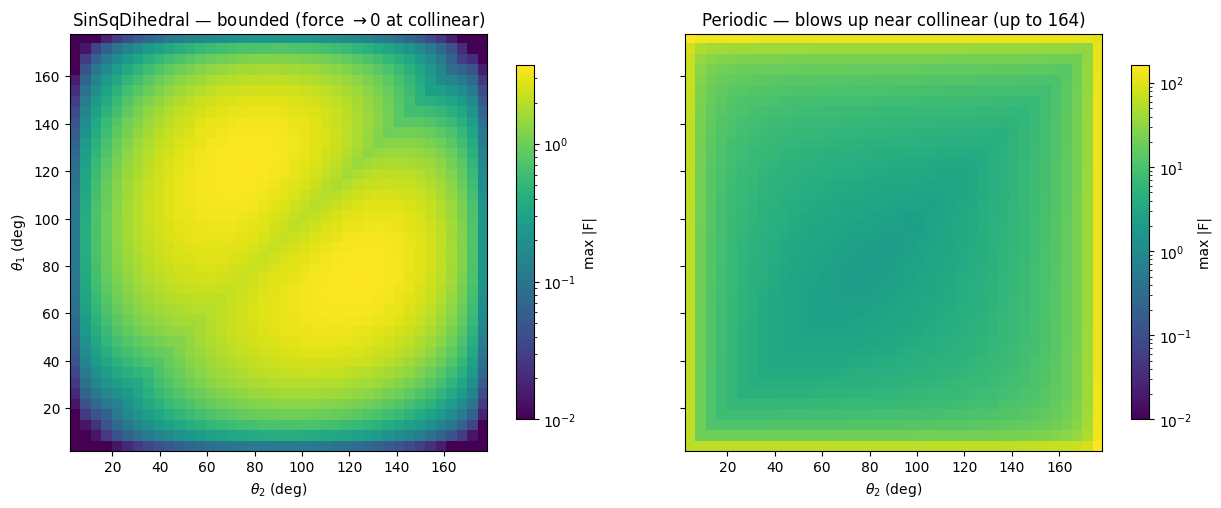

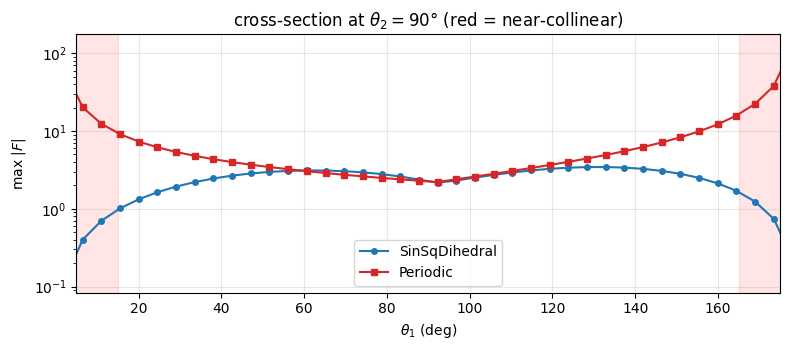

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
ext = [angles[0], angles[-1], angles[0], angles[-1]]
Fp_max = np.nanmax(np.where(np.isfinite(Fp), Fp, np.nan))
Fp_show = np.clip(np.where(np.isfinite(Fp), Fp, Fp_max), 0.01, None)
im0 = axes[0].imshow(Fs, origin="lower", extent=ext, aspect="equal", cmap="viridis",
                     norm=mcolors.LogNorm(vmin=0.01, vmax=Fs.max()))
axes[0].set_title(r"SinSqDihedral — bounded (force $\to 0$ at collinear)")
axes[0].set_ylabel(r"$\theta_1$ (deg)")
plt.colorbar(im0, ax=axes[0], shrink=0.85, label="max |F|")
im1 = axes[1].imshow(Fp_show, origin="lower", extent=ext, aspect="equal", cmap="viridis",
                     norm=mcolors.LogNorm(vmin=0.01, vmax=Fp_max))
axes[1].set_title(rf"Periodic — blows up near collinear (up to {Fp_max:.0f})")
for ax in axes:
    ax.set_xlabel(r"$\theta_2$ (deg)")
plt.colorbar(im1, ax=axes[1], shrink=0.85, label="max |F|")
fig.tight_layout(); plt.show()

j90 = np.argmin(np.abs(angles - 90))
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.semilogy(angles, Fs[:, j90], "o-", ms=4, label="SinSqDihedral", color="C0")
ax.semilogy(angles, np.clip(Fp[:, j90], 1e-3, None), "s-", ms=4, label="Periodic", color="C3")
ax.axvspan(0, 15, alpha=0.1, color="red"); ax.axvspan(165, 180, alpha=0.1, color="red")
ax.set_xlabel(r"$\theta_1$ (deg)"); ax.set_ylabel(r"max $|F|$"); ax.set_xlim(5, 175)
ax.set_title(r"cross-section at $\theta_2=90°$ (red = near-collinear)"); ax.legend()
ax.grid(alpha=0.3); fig.tight_layout(); plt.show()

## 2. A backbone helix

We build a linear chain with bonds, stiff-ish bending angles ($\theta_0=170°$, so the
backbone sits *near collinear* — exactly where the standard dihedral would
struggle), and a `SinSqDihedral` backbone torsion with a gauche ($\phi_0=60°$)
minimum. Soft **DPD** gives excluded volume. The chain folds into a helix.

In [4]:
N = 2000
THETA0 = np.radians(170.0)     # near-collinear: right where the standard dihedral struggles
PHI0 = np.pi / 3.0
kT, DT = 1.0, 0.005
DT_WARM, WARMUP = 5e-4, 8000
NUM_BLOCKS, BLOCK = 40, 1000

OUT_DIR = pathlib.Path("./sinsq_traj"); OUT_DIR.mkdir(exist_ok=True)
INIT_GSD, TRAJ_GSD = OUT_DIR / "init.gsd", OUT_DIR / "traj.gsd"

# random-walk backbone -> diverse (often near-collinear) initial bond angles
np.random.seed(0)
steps = np.random.normal(size=(N, 3)); steps /= np.linalg.norm(steps, axis=1, keepdims=True)
pos = np.cumsum(steps, axis=0).astype(float); pos[0] = 0.0; pos -= pos.mean(0)
L = float(np.ptp(pos, axis=0).max()) + 20.0

frame = gsd.hoomd.Frame()
frame.configuration.box = [L, L, L, 0, 0, 0]
frame.particles.N = N; frame.particles.types = ["B"]; frame.particles.typeid = np.zeros(N, int)
frame.particles.position = pos; frame.particles.mass = np.ones(N)
frame.bonds.N = N - 1; frame.bonds.types = ["backbone"]; frame.bonds.typeid = np.zeros(N - 1, int)
frame.bonds.group = np.column_stack([np.arange(N - 1), np.arange(1, N)])
frame.angles.N = N - 2; frame.angles.types = ["bend"]; frame.angles.typeid = np.zeros(N - 2, int)
frame.angles.group = np.column_stack([np.arange(N - 2), np.arange(1, N - 1), np.arange(2, N)])
frame.dihedrals.N = N - 3; frame.dihedrals.types = ["backbone"]
frame.dihedrals.typeid = np.zeros(N - 3, int)
frame.dihedrals.group = np.column_stack([np.arange(N - 3), np.arange(1, N - 2),
                                         np.arange(2, N - 1), np.arange(3, N)])
with gsd.hoomd.open(name=str(INIT_GSD), mode="w") as f:
    f.append(frame)
print(f"{N} beads; box L={L:.0f}; wrote {INIT_GSD}")

2000 beads; box L=72; wrote sinsq_traj/init.gsd


The force stack is reused for the stability test in Part 3, so we build it
from one factory `make_forces(dihedral)`.

In [5]:
def make_forces(dihedral):
    # bond + soft DPD excluded volume + bending + the dihedral under test.
    # Bond/angle are kept moderately soft on purpose: that way the *dihedral* is what
    # limits the time step, so the near-collinear singularity of Periodic (vs the
    # bounded SinSqDihedral) actually shows up in the stability sweep (Part 4).
    bond = hoomd.md.bond.Harmonic(); bond.params["backbone"] = dict(k=100.0, r0=1.0)
    nlist = hoomd.md.nlist.Cell(buffer=0.4, exclusions=["bond", "1-3"])
    dpd = hoomd.md.pair.DPDConservative(nlist=nlist, default_r_cut=1.0)
    dpd.params[("B", "B")] = dict(A=25.0)
    bend = hoomd.md.angle.Harmonic(); bend.params["bend"] = dict(k=50.0, t0=THETA0)
    return [bond, dpd, bend, dihedral]


def sinsq():
    f = glab_forces.SinSqDihedral(); f.params["backbone"] = dict(k=50.0, d=-1, n=1, phi0=PHI0)
    return f


def periodic():
    f = hoomd.md.dihedral.Periodic(); f.params["backbone"] = dict(k=50.0, d=-1, n=1, phi0=PHI0)
    return f

Run the helix under `SinSqDihedral`, streaming the trajectory and recording the (bounded) dihedral force.

In [6]:
sim = hoomd.Simulation(device=device, seed=42)
sim.create_state_from_gsd(filename=str(INIT_GSD))
dih = sinsq()
forces = make_forces(dih)
langevin = hoomd.md.methods.Langevin(filter=hoomd.filter.All(), kT=kT)
integ = hoomd.md.Integrator(dt=DT_WARM, methods=[langevin], forces=forces)
sim.operations.integrator = integ
thermo = hoomd.md.compute.ThermodynamicQuantities(filter=hoomd.filter.All())
sim.operations.computes.append(thermo)
writer = hoomd.write.GSD(filename=str(TRAJ_GSD), mode="wb",
                         trigger=hoomd.trigger.Periodic(BLOCK), dynamic=["property"])
sim.operations.writers.append(writer)

sim.run(WARMUP)                 # gentle warmup resolves the random-walk stress
integ.dt = DT
pe, fdih = [], []
for i in range(NUM_BLOCKS):
    sim.run(BLOCK)
    pe.append(thermo.potential_energy)
    fdih.append(float(np.linalg.norm(np.asarray(dih.forces), axis=1).max()))  # raw force, no analysis
    if (i + 1) % 10 == 0:
        print(f"block {i+1:2d}/{NUM_BLOCKS}  E_P/N = {thermo.potential_energy/N:7.3f}"
              f"  max|F_dih| = {fdih[-1]:.2f}")
writer.flush()
assert isinstance(dih, glab_forces.SinSqDihedral) and abs(dih.energy) > 0
print(f"[PASS] SinSqDihedral exercised; dihedral force stayed finite (max {max(fdih):.2f})")

block 10/40  E_P/N =   1.347  max|F_dih| = 24.42


block 20/40  E_P/N =   1.278  max|F_dih| = 31.92


block 30/40  E_P/N =   1.214  max|F_dih| = 25.46


block 40/40  E_P/N =   1.211  max|F_dih| = 22.73
[PASS] SinSqDihedral exercised; dihedral force stayed finite (max 38.34)


# ═══════ EXECUTION COMPLETE — VISUALIZATION & ANALYSIS BELOW ═══════

## 3. The folded helix, and the bounded dihedral force

The backbone (coloured by contour position) has folded into a compact helix.

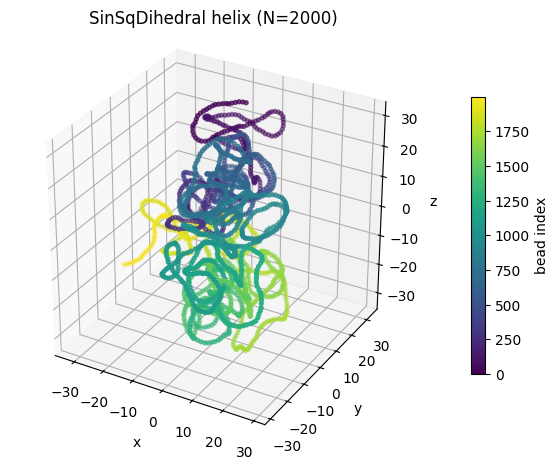

In [7]:
snap = sim.state.get_snapshot()
pf = v.unwrap(snap.particles.position, snap.particles.image, snap.configuration.box)
fig = plt.figure(figsize=(7, 6)); ax = fig.add_subplot(111, projection="3d")
v.render3d(pf, connect=True, color=np.arange(N), cmap="viridis", clabel="bead index",
           title=f"SinSqDihedral helix (N={N})", ax=ax)
plt.show()

Energy equilibrates and the dihedral force never spikes:

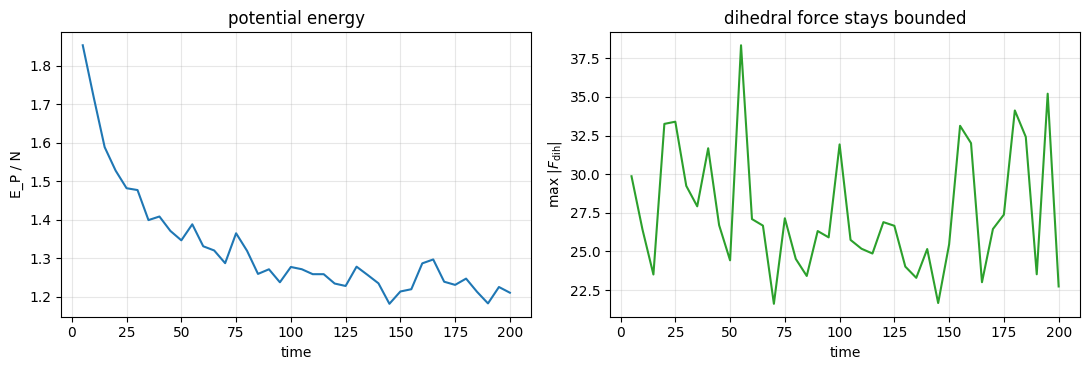

In [8]:
t = (np.arange(NUM_BLOCKS) + 1) * BLOCK * DT
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
a1.plot(t, np.array(pe) / N, color="C0"); a1.set_xlabel("time"); a1.set_ylabel("E_P / N")
a1.set_title("potential energy"); a1.grid(alpha=0.3)
a2.plot(t, fdih, color="C2"); a2.set_xlabel("time"); a2.set_ylabel(r"max $|F_\mathrm{dih}|$")
a2.set_title("dihedral force stays bounded"); a2.grid(alpha=0.3)
fig.tight_layout(); plt.show()

## 4. Time-step stability

Starting from the equilibrated helix, we sweep the time step for `SinSqDihedral`
vs `Periodic` (same $k$, same equilibrium). A run "survives" if kinetic energy and
positions stay finite for 10k steps. Because its force never diverges,
`SinSqDihedral` tolerates a much larger `dt`.

In [9]:
equil = sim.state.get_snapshot()
DT_SWEEP = [0.005, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.15]


def survives(make_dih, dt, n_steps=10000, check=1000):
    s = hoomd.Simulation(device=device, seed=7)
    s.create_state_from_snapshot(equil)
    lang = hoomd.md.methods.Langevin(filter=hoomd.filter.All(), kT=kT)
    s.operations.integrator = hoomd.md.Integrator(dt=dt, methods=[lang], forces=make_forces(make_dih()))
    th = hoomd.md.compute.ThermodynamicQuantities(filter=hoomd.filter.All())
    s.operations.computes.append(th)
    done = 0
    try:
        for _ in range(n_steps // check):
            s.run(check); done += check
            ke = th.kinetic_energy
            if not np.isfinite(ke) or ke / N > 1e4:
                return False, done
        return True, done
    except Exception:
        return False, done


rows = []
for dt in DT_SWEEP:
    ok_s, ds = survives(sinsq, dt)
    ok_p, dp = survives(periodic, dt)
    rows.append((dt, ok_s, ds, ok_p, dp))
    print(f"dt={dt:<6}  SinSq: {'PASS' if ok_s else 'FAIL @'+str(ds):<10}"
          f"  Periodic: {'PASS' if ok_p else 'FAIL @'+str(dp)}")
max_s = max((dt for dt, a, _, _, _ in rows if a), default=0)
max_p = max((dt for dt, _, _, a, _ in rows if a), default=0)
print(f"\nmax stable dt:  SinSqDihedral = {max_s},  Periodic = {max_p}"
      + (f"  ({max_s/max_p:.0f}x larger)" if max_p else ""))

dt=0.005   SinSq: PASS        Periodic: PASS


dt=0.01    SinSq: PASS        Periodic: PASS


dt=0.02    SinSq: PASS        Periodic: PASS


dt=0.03    SinSq: PASS        Periodic: PASS


dt=0.05    SinSq: PASS        Periodic: FAIL @1000


dt=0.07    SinSq: FAIL @6000  Periodic: FAIL @0


dt=0.1     SinSq: FAIL @0     Periodic: FAIL @0


dt=0.15    SinSq: FAIL @0     Periodic: FAIL @0

max stable dt:  SinSqDihedral = 0.05,  Periodic = 0.03  (2x larger)


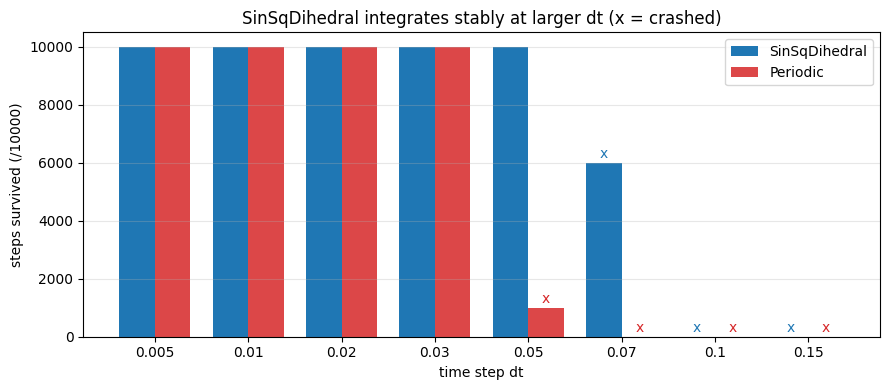

In [10]:
x = np.arange(len(DT_SWEEP)); w = 0.38
ss = [r[2] for r in rows]; pp = [r[4] for r in rows]
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, ss, w, label="SinSqDihedral", color="C0")
ax.bar(x + w/2, pp, w, label="Periodic", color="C3", alpha=0.85)
for i, r in enumerate(rows):
    if not r[1]: ax.text(i - w/2, r[2] + 150, "x", ha="center", color="C0")
    if not r[3]: ax.text(i + w/2, r[4] + 150, "x", ha="center", color="C3")
ax.set_xticks(x); ax.set_xticklabels([str(d) for d in DT_SWEEP])
ax.set_xlabel("time step dt"); ax.set_ylabel("steps survived (/10000)")
ax.set_title("SinSqDihedral integrates stably at larger dt (x = crashed)")
ax.legend(); ax.grid(alpha=0.3, axis="y"); fig.tight_layout(); plt.show()

## What to try next

- **Stiffer bending** ($\theta_0 \to 175°$) pushes the backbone even closer to
  collinear — `Periodic`'s stable `dt` shrinks further while `SinSqDihedral` is
  unaffected.
- **Change the helix:** `phi0` sets the gauche angle and `n` the number of minima
  per turn — the pitch and handedness of the folded helix follow.
- **Bounded landscape:** re-run Part 1 at other `phi` slices — `SinSqDihedral`
  stays bounded everywhere; `Periodic` diverges along the collinear edges.